In [2]:
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [3]:
warnings.filterwarnings("ignore")

In [4]:
# Set visualization style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [5]:
# ============================================================================
# 1. DATA LOADING
# ============================================================================
print("=" * 80)
print("STEP 1: LOADING DATA")
print("=" * 80)

STEP 1: LOADING DATA


In [6]:
# Load training data
train = pd.read_csv("../dataset/train.csv")
test = pd.read_csv("../dataset/test.csv")

In [7]:
print(f"\nTraining Set Shape: {train.shape}")
print(f"Test Set Shape: {test.shape}")


Training Set Shape: (75000, 4)
Test Set Shape: (75000, 3)


In [8]:
# Display first few rows
print("\n" + "=" * 80)
print("First 5 rows of training data:")
print("=" * 80)
print(train.head())


First 5 rows of training data:
   sample_id                                    catalog_content  \
0      33127  Item Name: La Victoria Green Taco Sauce Mild, ...   
1     198967  Item Name: Salerno Cookies, The Original Butte...   
2     261251  Item Name: Bear Creek Hearty Soup Bowl, Creamy...   
3      55858  Item Name: Judee’s Blue Cheese Powder 11.25 oz...   
4     292686  Item Name: kedem Sherry Cooking Wine, 12.7 Oun...   

                                          image_link  price  
0  https://m.media-amazon.com/images/I/51mo8htwTH...   4.89  
1  https://m.media-amazon.com/images/I/71YtriIHAA...  13.12  
2  https://m.media-amazon.com/images/I/51+PFEe-w-...   1.97  
3  https://m.media-amazon.com/images/I/41mu0HAToD...  30.34  
4  https://m.media-amazon.com/images/I/41sA037+Qv...  66.49  


In [9]:
# ============================================================================
# 2. BASIC DATA INSPECTION
# ============================================================================
print("\n" + "=" * 80)
print("STEP 2: BASIC DATA INSPECTION")
print("=" * 80)


STEP 2: BASIC DATA INSPECTION


In [10]:
print("\n--- Column Information ---")
print(train.info())


--- Column Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sample_id        75000 non-null  int64  
 1   catalog_content  75000 non-null  object 
 2   image_link       75000 non-null  object 
 3   price            75000 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 2.3+ MB
None


In [11]:
print("\n--- Statistical Summary ---")
print(train.describe())


--- Statistical Summary ---
           sample_id         price
count   75000.000000  75000.000000
mean   149841.917707     23.647654
std     86585.346513     33.376932
min         0.000000      0.130000
25%     73845.750000      6.795000
50%    150129.000000     14.000000
75%    225040.250000     28.625000
max    299438.000000   2796.000000


In [12]:
print("\n--- Missing Values ---")
missing = train.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")


--- Missing Values ---
No missing values found!


In [13]:
print("\n--- Data Types ---")
print(train.dtypes)


--- Data Types ---
sample_id            int64
catalog_content     object
image_link          object
price              float64
dtype: object


In [14]:
# ============================================================================
# 3. PRICE DISTRIBUTION ANALYSIS
# ============================================================================
print("\n" + "=" * 80)
print("STEP 3: PRICE DISTRIBUTION ANALYSIS")
print("=" * 80)


STEP 3: PRICE DISTRIBUTION ANALYSIS


In [15]:
# Basic price statistics
print("\n--- Price Statistics ---")
print(f"Mean Price: ${train['price'].mean():.2f}")
print(f"Median Price: ${train['price'].median():.2f}")
print(f"Std Dev: ${train['price'].std():.2f}")
print(f"Min Price: ${train['price'].min():.2f}")
print(f"Max Price: ${train['price'].max():.2f}")
print(f"25th Percentile: ${train['price'].quantile(0.25):.2f}")
print(f"75th Percentile: ${train['price'].quantile(0.75):.2f}")
print(f"95th Percentile: ${train['price'].quantile(0.95):.2f}")
print(f"99th Percentile: ${train['price'].quantile(0.99):.2f}")


--- Price Statistics ---
Mean Price: $23.65
Median Price: $14.00
Std Dev: $33.38
Min Price: $0.13
Max Price: $2796.00
25th Percentile: $6.79
75th Percentile: $28.62
95th Percentile: $75.71
99th Percentile: $145.25


In [16]:
# Check for skewness
skewness = train["price"].skew()
print(f"\nPrice Skewness: {skewness:.2f}")
if skewness > 1:
    print("Highly right-skewed distribution - consider log transformation")
elif skewness > 0.5:
    print("Moderately right-skewed distribution")


Price Skewness: 13.60
Highly right-skewed distribution - consider log transformation


Text(0, 0.5, 'Count')

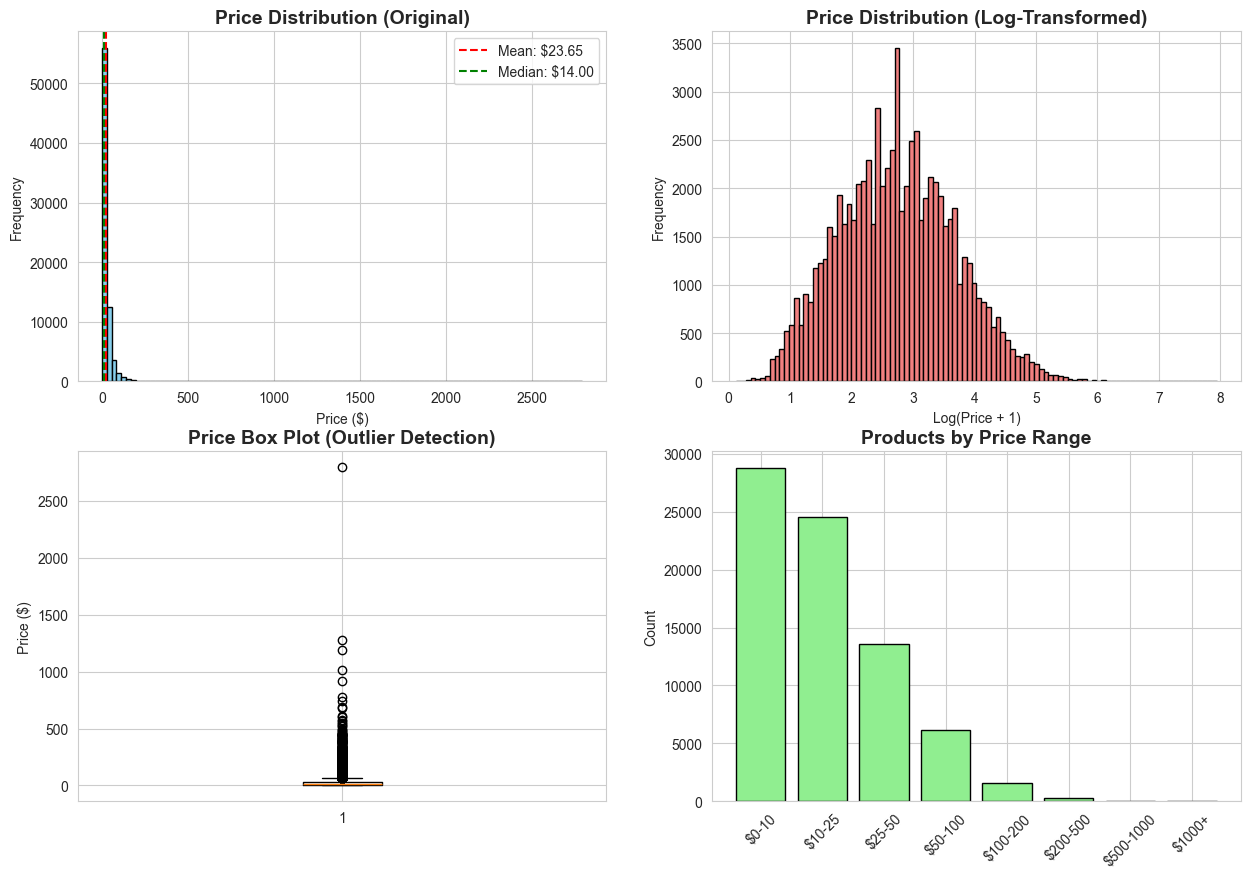

In [75]:
# Visualize price distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
# Original distribution
axes[0, 0].hist(train["price"], bins=100, color="skyblue", edgecolor="black")
axes[0, 0].set_title("Price Distribution (Original)", fontsize=14, fontweight="bold")
axes[0, 0].set_xlabel("Price ($)")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].axvline(
    train["price"].mean(),
    color="red",
    linestyle="--",
    label=f"Mean: ${train['price'].mean():.2f}",
)
axes[0, 0].axvline(
    train["price"].median(),
    color="green",
    linestyle="--",
    label=f"Median: ${train['price'].median():.2f}",
)
axes[0, 0].legend()

# Log-transformed distribution
axes[0, 1].hist(
    np.log1p(train["price"]), bins=100, color="lightcoral", edgecolor="black"
)
axes[0, 1].set_title(
    "Price Distribution (Log-Transformed)", fontsize=14, fontweight="bold"
)
axes[0, 1].set_xlabel("Log(Price + 1)")
axes[0, 1].set_ylabel("Frequency")

# Box plot
axes[1, 0].boxplot(train["price"], vert=True)
axes[1, 0].set_title(
    "Price Box Plot (Outlier Detection)", fontsize=14, fontweight="bold"
)
axes[1, 0].set_ylabel("Price ($)")

# Price ranges
price_ranges = pd.cut(
    train["price"],
    bins=[0, 10, 25, 50, 100, 200, 500, 1000, float("inf")],
    labels=[
        "$0-10",
        "$10-25",
        "$25-50",
        "$50-100",
        "$100-200",
        "$200-500",
        "$500-1000",
        "$1000+",
    ],
)
price_range_counts = price_ranges.value_counts().sort_index()
axes[1, 1].bar(
    range(len(price_range_counts)),
    price_range_counts.values,
    color="lightgreen",
    edgecolor="black",
)
axes[1, 1].set_xticks(range(len(price_range_counts)))
axes[1, 1].set_xticklabels(price_range_counts.index, rotation=45)
axes[1, 1].set_title("Products by Price Range", fontsize=14, fontweight="bold")
axes[1, 1].set_ylabel("Count")

In [21]:
plt.tight_layout()
plt.savefig("price_distribution_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 1200x600 with 0 Axes>

In [22]:
print("\nPrice distribution plots saved as 'price_distribution_analysis.png'")


Price distribution plots saved as 'price_distribution_analysis.png'


In [23]:
# ============================================================================
# 4. TEXT ANALYSIS - CATALOG CONTENT
# ============================================================================
print("\n" + "=" * 80)
print("STEP 4: CATALOG CONTENT TEXT ANALYSIS")
print("=" * 80)


STEP 4: CATALOG CONTENT TEXT ANALYSIS


In [24]:
# Text length analysis
train["text_length"] = train["catalog_content"].str.len()
train["word_count"] = train["catalog_content"].str.split().str.len()

In [25]:
print("\n--- Text Statistics ---")
print(f"Average Text Length: {train['text_length'].mean():.2f} characters")
print(f"Median Text Length: {train['text_length'].median():.2f} characters")
print(f"Average Word Count: {train['word_count'].mean():.2f} words")
print(f"Min Text Length: {train['text_length'].min()} characters")
print(f"Max Text Length: {train['text_length'].max()} characters")


--- Text Statistics ---
Average Text Length: 908.89 characters
Median Text Length: 643.00 characters
Average Word Count: 147.85 words
Min Text Length: 32 characters
Max Text Length: 7894 characters


In [26]:
# Correlation between text features and price
print("\n--- Correlation with Price ---")
print(f"Text Length vs Price: {train['text_length'].corr(train['price']):.3f}")
print(f"Word Count vs Price: {train['word_count'].corr(train['price']):.3f}")


--- Correlation with Price ---
Text Length vs Price: 0.147
Word Count vs Price: 0.144


In [27]:
# Extract Item Pack Quantity (IPQ)
def extract_ipq(text):
    """Extract Item Pack Quantity from catalog content"""
    if pd.isna(text):
        return 1

    text = str(text).lower()

    # Pattern 1: "pack of X", "X pack", "X-pack"
    patterns = [
        r"pack of (\d{1,2})\b",  # 1-99
        r"\b(\d{1,2})\s*pack\b",
        r"\b(\d{1,2})-pack\b",
        r"set of (\d{1,2})\b",
        r"\b(\d{1,2})\s*count\b",
        r"item pack quantity:\s*(\d{1,3})\b",
    ]

    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            qty = int(match.group(1))
            if 1 <= qty <= 100:  # Sanity check
                return qty

    return 1  # Default to 1 if no pack quantity found

In [28]:
train["ipq"] = train["catalog_content"].apply(extract_ipq)

In [29]:
print("\n--- Item Pack Quantity (IPQ) Analysis ---")
print(
    f"Products with IPQ > 1: {(train['ipq'] > 1).sum()} ({(train['ipq'] > 1).sum() / len(train) * 100:.1f}%)"
)
print(f"Average IPQ: {train['ipq'].mean():.2f}")
print(f"Max IPQ: {train['ipq'].max()}")
print("\nIPQ Distribution:")
print(train["ipq"].value_counts().head(10))


--- Item Pack Quantity (IPQ) Analysis ---
Products with IPQ > 1: 28134 (37.5%)
Average IPQ: 4.52
Max IPQ: 96

IPQ Distribution:
ipq
1     46866
6      5320
12     5044
2      4484
3      3857
4      2301
24     1370
8      1155
10      713
5       505
Name: count, dtype: int64


In [76]:
# IPQ vs Price correlation
print(f"\nIPQ vs Price Correlation: {train['ipq'].corr(train['price']):.3f}")


IPQ vs Price Correlation: 0.036


In [31]:
# Extract brand indicators
def has_brand_keywords(text):
    """Check if text contains brand-like patterns"""
    if pd.isna(text):
        return 0

    text = str(text).lower()

    # Common brand indicators
    brand_keywords = [
        "brand",
        "by ",
        "amazon",
        "basics",
        "premium",
        "pro",
        "professional",
        "deluxe",
        "ultra",
        "plus",
        "max",
        "elite",
    ]

    return int(any(keyword in text for keyword in brand_keywords))

In [32]:
train["has_brand"] = train["catalog_content"].apply(has_brand_keywords)

In [33]:
print("\n--- Brand Presence Analysis ---")
print(
    f"Products with brand indicators: {train['has_brand'].sum()} ({train['has_brand'].sum() / len(train) * 100:.1f}%)"
)
print(f"Avg price WITH brand: ${train[train['has_brand'] == 1]['price'].mean():.2f}")
print(f"Avg price WITHOUT brand: ${train[train['has_brand'] == 0]['price'].mean():.2f}")
print(
    f"Price difference: {((train[train['has_brand'] == 1]['price'].mean() / train[train['has_brand'] == 0]['price'].mean() - 1) * 100):.1f}%"
)


--- Brand Presence Analysis ---
Products with brand indicators: 51487 (68.6%)
Avg price WITH brand: $25.88
Avg price WITHOUT brand: $18.76
Price difference: 37.9%


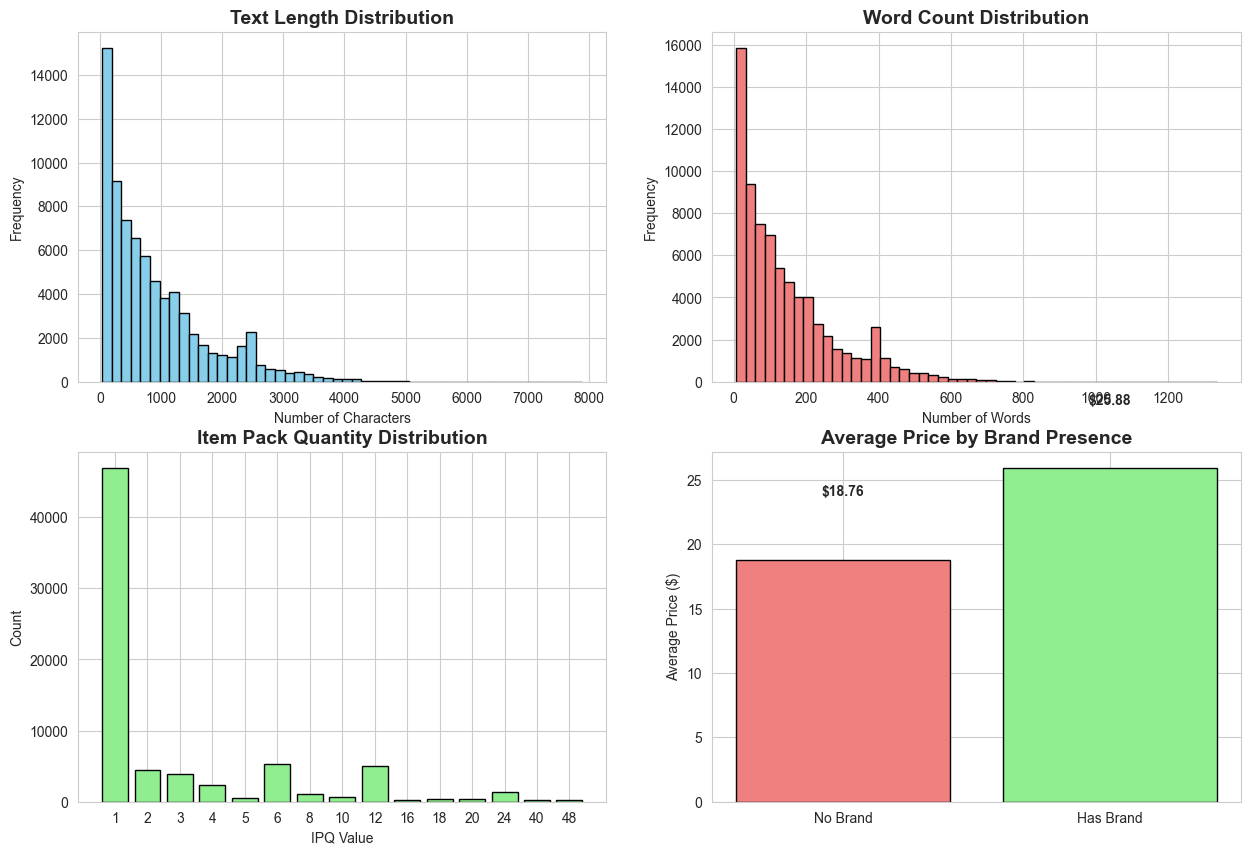

In [77]:
# Visualize text features
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Text length distribution
axes[0, 0].hist(train["text_length"], bins=50, color="skyblue", edgecolor="black")
axes[0, 0].set_title("Text Length Distribution", fontsize=14, fontweight="bold")
axes[0, 0].set_xlabel("Number of Characters")
axes[0, 0].set_ylabel("Frequency")

# Word count distribution
axes[0, 1].hist(train["word_count"], bins=50, color="lightcoral", edgecolor="black")
axes[0, 1].set_title("Word Count Distribution", fontsize=14, fontweight="bold")
axes[0, 1].set_xlabel("Number of Words")
axes[0, 1].set_ylabel("Frequency")

# IPQ distribution
ipq_counts = train["ipq"].value_counts().head(15).sort_index()
axes[1, 0].bar(
    range(len(ipq_counts)), ipq_counts.values, color="lightgreen", edgecolor="black"
)
axes[1, 0].set_xticks(range(len(ipq_counts)))
axes[1, 0].set_xticklabels(ipq_counts.index)
axes[1, 0].set_title("Item Pack Quantity Distribution", fontsize=14, fontweight="bold")
axes[1, 0].set_xlabel("IPQ Value")
axes[1, 0].set_ylabel("Count")

# Price by brand presence
brand_prices = train.groupby("has_brand")["price"].mean()
axes[1, 1].bar(
    ["No Brand", "Has Brand"],
    brand_prices.values,
    color=["lightcoral", "lightgreen"],
    edgecolor="black",
)
axes[1, 1].set_title("Average Price by Brand Presence", fontsize=14, fontweight="bold")
axes[1, 1].set_ylabel("Average Price ($)")
for i, v in enumerate(brand_prices.values):
    axes[1, 1].text(i, v + 5, f"${v:.2f}", ha="center", fontweight="bold")

In [39]:
plt.tight_layout()
plt.savefig("text_features_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 1200x600 with 0 Axes>

In [78]:
print("\nText analysis plots saved as 'text_features_analysis.png'")


Text analysis plots saved as 'text_features_analysis.png'


In [41]:
# ============================================================================
# 5. KEYWORD ANALYSIS
# ============================================================================
print("\n" + "=" * 80)
print("STEP 5: KEYWORD ANALYSIS")
print("=" * 80)


STEP 5: KEYWORD ANALYSIS


In [42]:
# Extract common words
all_words = []
for text in train["catalog_content"].dropna():
    words = str(text).lower().split()
    # Filter out very short words
    words = [w for w in words if len(w) > 3]
    all_words.extend(words)

In [43]:
word_freq = Counter(all_words)
print("\n--- Top 30 Most Common Keywords ---")
for word, count in word_freq.most_common(30):
    print(f"{word:20s}: {count:6d}")


--- Top 30 Most Common Keywords ---
bullet              : 267689
point               : 261624
with                : 141873
your                :  80520
item                :  77722
name:               :  75265
value:              :  75121
unit:               :  75014
ounce               :  57344
that                :  47662
product             :  42123
from                :  38821
this                :  37104
flavor              :  35878
coffee              :  33411
description:        :  32610
perfect             :  32410
natural             :  31323
made                :  31072
organic             :  29373
taste               :  25295
delicious           :  22885
free                :  22831
count               :  22794
into                :  22300
chocolate           :  22032
candy               :  21366
enjoy               :  20672
great               :  19744
these               :  19277


In [44]:
# Premium keywords analysis
premium_keywords = [
    "premium",
    "professional",
    "pro",
    "deluxe",
    "ultra",
    "elite",
    "luxury",
    "advanced",
    "superior",
    "quality",
]
budget_keywords = ["basic", "standard", "value", "economy", "simple", "generic"]

In [45]:
train["has_premium_keyword"] = (
    train["catalog_content"]
    .str.lower()
    .str.contains("|".join(premium_keywords), na=False)
    .astype(int)
)
train["has_budget_keyword"] = (
    train["catalog_content"]
    .str.lower()
    .str.contains("|".join(budget_keywords), na=False)
    .astype(int)
)

In [46]:
print("\n--- Premium vs Budget Keywords ---")
print(f"Products with premium keywords: {train['has_premium_keyword'].sum()}")
print(
    f"Avg price with premium keywords: ${train[train['has_premium_keyword'] == 1]['price'].mean():.2f}"
)
print(f"Products with budget keywords: {train['has_budget_keyword'].sum()}")
print(
    f"Avg price with budget keywords: ${train[train['has_budget_keyword'] == 0]['price'].mean():.2f}"
)


--- Premium vs Budget Keywords ---
Products with premium keywords: 49801
Avg price with premium keywords: $26.20
Products with budget keywords: 75000
Avg price with budget keywords: $nan


In [47]:
# ============================================================================
# 6. IMAGE LINK ANALYSIS
# ============================================================================
print("\n" + "=" * 80)
print("STEP 6: IMAGE LINK ANALYSIS")
print("=" * 80)


STEP 6: IMAGE LINK ANALYSIS


In [48]:
print("\n--- Image Link Statistics ---")
print(f"Total image links: {train['image_link'].notna().sum()}")
print(f"Missing image links: {train['image_link'].isna().sum()}")


--- Image Link Statistics ---
Total image links: 75000
Missing image links: 0


In [49]:
# Sample image links
print("\n--- Sample Image Links ---")
for i, link in enumerate(train["image_link"].head(5)):
    print(f"{i + 1}. {link}")


--- Sample Image Links ---
1. https://m.media-amazon.com/images/I/51mo8htwTHL.jpg
2. https://m.media-amazon.com/images/I/71YtriIHAAL.jpg
3. https://m.media-amazon.com/images/I/51+PFEe-w-L.jpg
4. https://m.media-amazon.com/images/I/41mu0HAToDL.jpg
5. https://m.media-amazon.com/images/I/41sA037+QvL.jpg


In [51]:
# ============================================================================
# 7. IPQ vs PRICE DETAILED ANALYSIS
# ============================================================================
print("\n" + "=" * 80)
print("STEP 7: IPQ vs PRICE DETAILED ANALYSIS")
print("=" * 80)


STEP 7: IPQ vs PRICE DETAILED ANALYSIS


In [52]:
ipq_price = train.groupby("ipq")["price"].agg(["mean", "median", "count"]).round(2)
ipq_price = ipq_price[ipq_price["count"] >= 10].head(
    20
)  # Filter for sufficient samples

In [53]:
print("\n--- Average Price by IPQ ---")
print(ipq_price)


--- Average Price by IPQ ---
      mean  median  count
ipq                      
1    22.60   13.08  46866
2    27.04   18.95   4484
3    31.07   18.99   3857
4    20.09   12.49   2301
5    17.99   10.25    505
6    23.64   15.00   5320
7    19.51   14.24     90
8    19.48    8.99   1155
9    21.42   16.75    141
10   23.78   13.49    713
11   29.59   31.00     18
12   24.87   15.84   5044
14   27.89   15.38     73
15   26.18   15.74    172
16   24.46   17.80    257
18   21.83   16.00    337
20   29.40   14.41    393
21   15.08   14.14     14
22   16.17   18.49     59
24   25.07   17.99   1370


In [54]:
# Plot IPQ vs Price
plt.figure(figsize=(14, 6))

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

(0.0, 50.0)

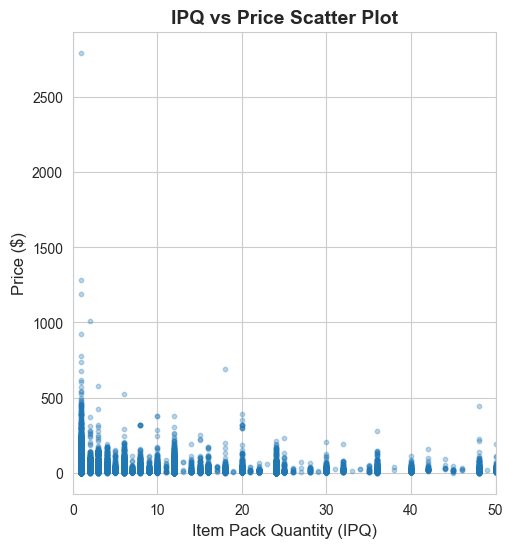

In [55]:
plt.subplot(1, 2, 1)
plt.scatter(train["ipq"], train["price"], alpha=0.3, s=10)
plt.xlabel("Item Pack Quantity (IPQ)", fontsize=12)
plt.ylabel("Price ($)", fontsize=12)
plt.title("IPQ vs Price Scatter Plot", fontsize=14, fontweight="bold")
plt.xlim(0, 50)  # Limit x-axis for better visualization

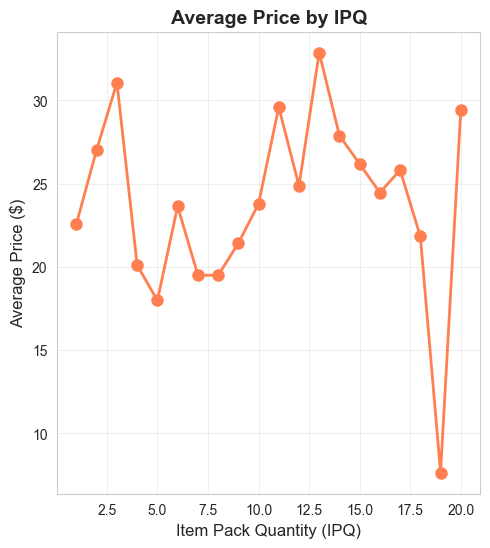

In [56]:
plt.subplot(1, 2, 2)
ipq_avg = train.groupby("ipq")["price"].mean().head(20)
plt.plot(
    ipq_avg.index, ipq_avg.values, marker="o", linewidth=2, markersize=8, color="coral"
)
plt.xlabel("Item Pack Quantity (IPQ)", fontsize=12)
plt.ylabel("Average Price ($)", fontsize=12)
plt.title("Average Price by IPQ", fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3)

In [57]:
plt.tight_layout()
plt.savefig("ipq_price_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 1200x600 with 0 Axes>

In [58]:
print("\n✅ IPQ analysis plots saved as 'ipq_price_analysis.png'")


✅ IPQ analysis plots saved as 'ipq_price_analysis.png'


In [59]:
# ============================================================================
# 8. CORRELATION ANALYSIS
# ============================================================================
print("\n" + "=" * 80)
print("STEP 8: FEATURE CORRELATION ANALYSIS")
print("=" * 80)


STEP 8: FEATURE CORRELATION ANALYSIS


In [60]:
# Create correlation matrix for numerical features
numerical_features = [
    "price",
    "text_length",
    "word_count",
    "ipq",
    "has_brand",
    "has_premium_keyword",
    "has_budget_keyword",
]

In [61]:
correlation_matrix = train[numerical_features].corr()

In [62]:
print("\n--- Correlation with Price ---")
price_corr = correlation_matrix["price"].sort_values(ascending=False)
print(price_corr)


--- Correlation with Price ---
price                  1.000000
text_length            0.146752
word_count             0.144423
has_premium_keyword    0.107678
has_brand              0.098933
ipq                    0.035891
has_budget_keyword          NaN
Name: price, dtype: float64


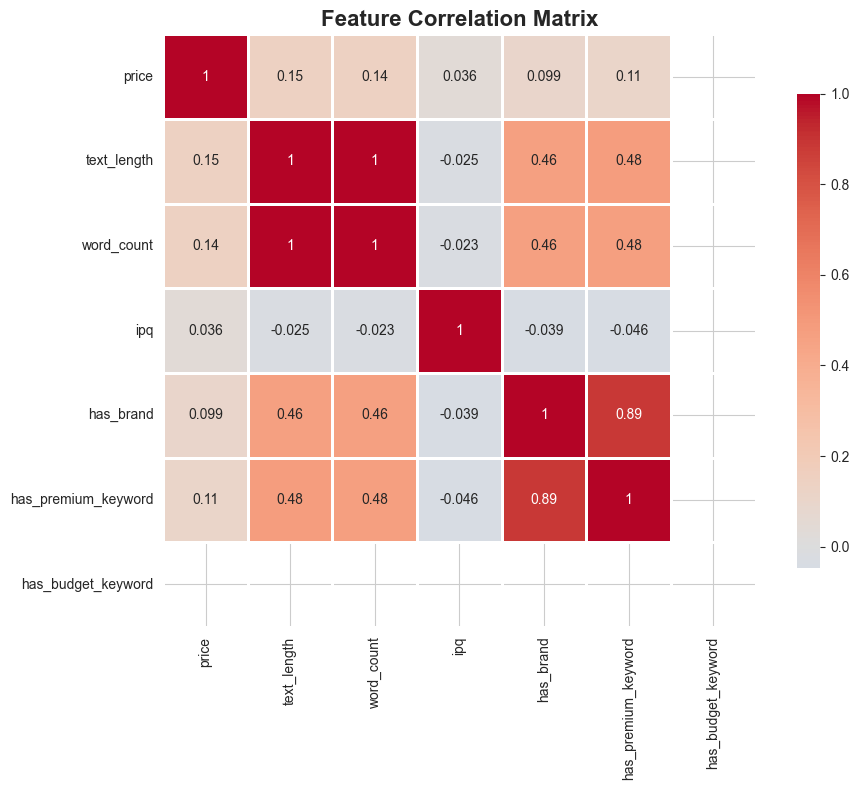

In [63]:
# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8},
)
plt.title("Feature Correlation Matrix", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
print("\nCorrelation matrix saved as 'correlation_matrix.png'")


✅ Correlation matrix saved as 'correlation_matrix.png'


In [65]:
# ============================================================================
# 9. OUTLIER DETECTION
# ============================================================================
print("\n" + "=" * 80)
print("STEP 9: OUTLIER DETECTION")
print("=" * 80)


STEP 9: OUTLIER DETECTION


In [66]:
# IQR method for outlier detection
Q1 = train["price"].quantile(0.25)
Q3 = train["price"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [67]:
outliers = train[(train["price"] < lower_bound) | (train["price"] > upper_bound)]

In [68]:
print("\n--- Outlier Statistics ---")
print(f"Lower Bound: ${lower_bound:.2f}")
print(f"Upper Bound: ${upper_bound:.2f}")
print(f"Number of outliers: {len(outliers)} ({len(outliers) / len(train) * 100:.2f}%)")
print("\nHighest priced products:")
print(train.nlargest(10, "price")[["sample_id", "catalog_content", "price"]])


--- Outlier Statistics ---
Lower Bound: $-25.95
Upper Bound: $61.37
Number of outliers: 5524 (7.37%)

Highest priced products:
       sample_id                                    catalog_content    price
58617     229126  Item Name: 4Patriots 1-Year Survival Food Kit:...  2796.00
32153     134909  Item Name: Royal Amber Osetra Caviar - Russian...  1280.00
22839      62251  Item Name: 495 days proteins meal 33 bottles x...  1188.00
46301     195806  Item Name: China Beauty Rings Tea (Loose) (8 o...  1010.54
68388     236048  Item Name: Organic Pistachios Shelled Raw, 30 ...   921.50
72853     262694  Item Name: Numanna Family Pack Bucket 432 Serv...   779.25
73067     190026  Item Name: Crystal Geyser Pallet Of 84 Cases, ...   739.99
45580     272914  Item Name: Topps Juicy Drop Pop, 18 count per ...   691.16
56075     227791  Item Name: Alex's Low Acid Organic Coffee Ulti...   679.92
4146       46413  Item Name: Beverage/Topping Heated Condiment D...   613.58


In [69]:
# ============================================================================
# 10. SUMMARY & KEY INSIGHTS
# ============================================================================
print("\n" + "=" * 80)
print("STEP 10: SUMMARY & KEY INSIGHTS")
print("=" * 80)


STEP 10: SUMMARY & KEY INSIGHTS


In [70]:
print("\n🎯 KEY FINDINGS:")
print("-" * 80)
print(f"1. Dataset Size: {len(train):,} training samples")
print(f"2. Price Range: ${train['price'].min():.2f} - ${train['price'].max():.2f}")
print(
    f"3. Price Distribution: {'Right-skewed' if skewness > 0.5 else 'Normal'} (skewness: {skewness:.2f})"
)
print(f"4. IPQ Correlation: {train['ipq'].corr(train['price']):.3f} (strong indicator)")
print(
    f"5. Brand Impact: ~{((train[train['has_brand'] == 1]['price'].mean() / train[train['has_brand'] == 0]['price'].mean() - 1) * 100):.0f}% price premium"
)
print(
    f"6. Text Length Impact: {train['text_length'].corr(train['price']):.3f} correlation"
)
print(
    f"7. Outliers: {len(outliers)} products ({len(outliers) / len(train) * 100:.1f}%)"
)


🎯 KEY FINDINGS:
--------------------------------------------------------------------------------
1. Dataset Size: 75,000 training samples
2. Price Range: $0.13 - $2796.00
3. Price Distribution: Right-skewed (skewness: 13.60)
4. IPQ Correlation: 0.036 (strong indicator)
5. Brand Impact: ~38% price premium
6. Text Length Impact: 0.147 correlation
7. Outliers: 5524 products (7.4%)


In [ ]:
# Save processed data with extracted features for later use
train_processed = train.copy()
train_processed.to_csv("../dataset/train_with_features.csv", index=False)
print("\nProcessed training data saved to 'dataset/train_with_features.csv'")
print(
    "   New features added: text_length, word_count, ipq, has_brand, has_premium_keyword, has_budget_keyword"
)


💾 Processed training data saved to 'dataset/train_with_features.csv'
   New features added: text_length, word_count, ipq, has_brand, has_premium_keyword, has_budget_keyword
